<a href="https://colab.research.google.com/github/bodkhesakshi03-dotcom/Python_Libraries_Assignment_Solutions/blob/main/s_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("ford_car_dataset.csv")

print(df.head(10))   # First 10 rows
print(df.tail(5))    # Last 5 rows
print("Shape:", df.shape)   # Rows × Columns
print(df.dtypes)     # Data types of columns

     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    16700   Petrol  150  47.1  

In [3]:
print(df.isnull().sum())       # Missing values per column
print("Duplicate rows:", df.duplicated().sum())  # Count duplicates

df = df.drop_duplicates()      # Remove duplicates


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
Duplicate rows: 154


In [4]:
print(df.describe())           # Summary of numeric columns
print(df['price'].describe())  # Price stats
print(df['mileage'].describe())# Mileage stats
print(df['year'].describe())   # Year stats


               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  
count    17812.000000
mean     12269.556310
std       4736.285417
min        495.

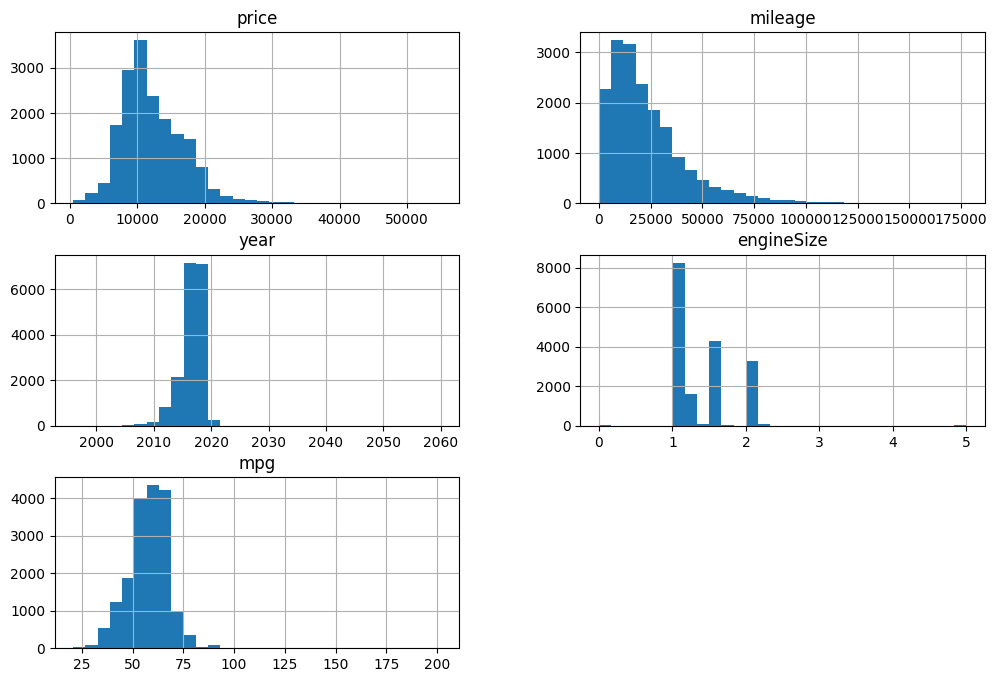

In [5]:
import matplotlib.pyplot as plt

numeric_cols = ['price','mileage','year','engineSize','mpg']
df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.show()


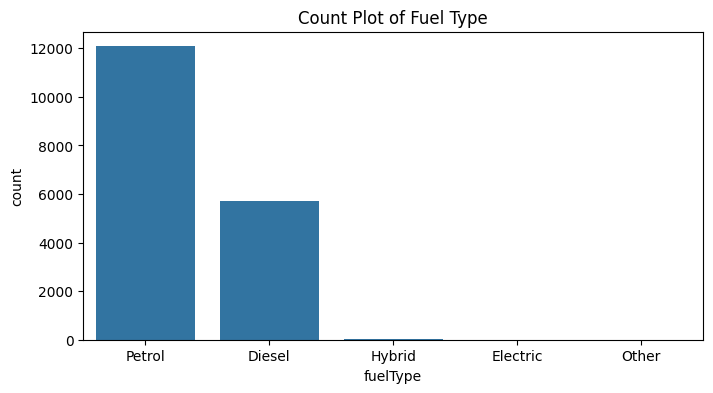

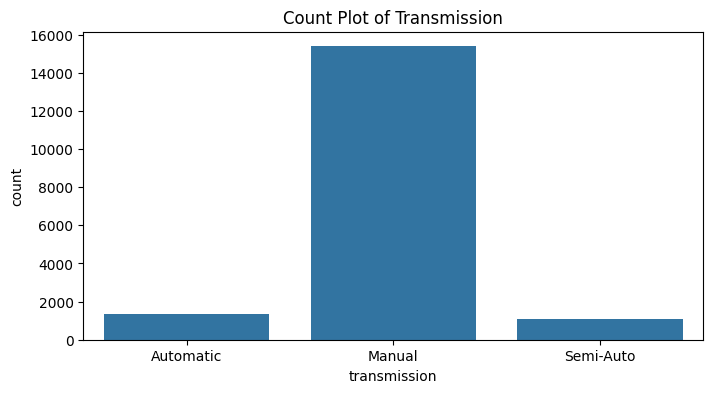

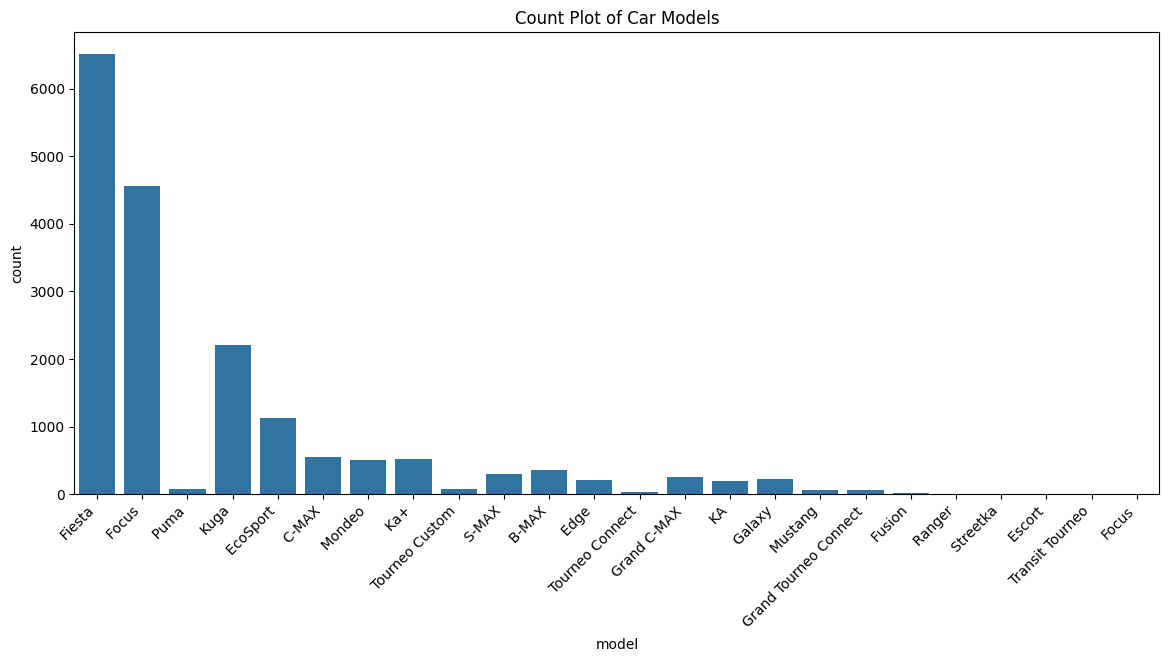

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for fuelType
plt.figure(figsize=(8,4))
sns.countplot(x="fuelType", data=df)
plt.title("Count Plot of Fuel Type")
plt.show()

# Count plot for transmission
plt.figure(figsize=(8,4))
sns.countplot(x="transmission", data=df)
plt.title("Count Plot of Transmission")
plt.show()

# Count plot for model
plt.figure(figsize=(14,6))
sns.countplot(x="model", data=df)
plt.xticks(rotation=45, ha="right")   # rotate labels for clarity
plt.title("Count Plot of Car Models")
plt.show()


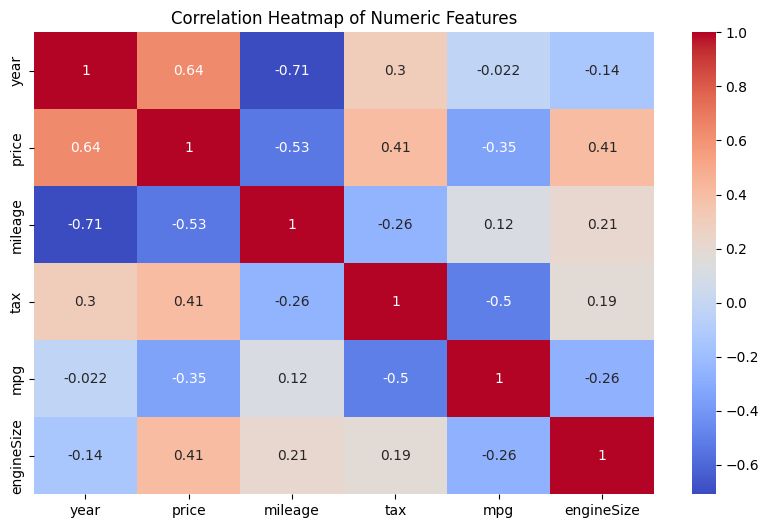

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64','float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Comments:
# - Only numeric features are included in correlation.
# - This avoids errors from string/categorical columns.
# - Heatmap shows which numeric features (like mileage, year, engineSize, mpg) are correlated with price.



In [16]:
print(df[['fuelType','transmission']].head())   # Before encoding

df_encoded = pd.get_dummies(df, columns=['fuelType','transmission'], drop_first=True)

print(df_encoded.head())   # After encoding



  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic
     model  year  price  mileage  tax   mpg  engineSize  fuelType_Electric  \
0   Fiesta  2017  12000    15944  150  57.7         1.0              False   
1    Focus  2018  14000     9083  150  57.7         1.0              False   
2    Focus  2017  13000    12456  150  57.7         1.0              False   
3   Fiesta  2019  17500    10460  145  40.3         1.5              False   
4   Fiesta  2019  16500     1482  145  48.7         1.0              False   

   fuelType_Hybrid  fuelType_Other  fuelType_Petrol  transmission_Manual  \
0            False           False             True                False   
1            False           False             True                 True   
2            False           False             True                 True   
3            False           False             True                 True   
4      

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_features = ['mileage','year','engineSize','mpg']
df_scaled = scaler.fit_transform(df[numeric_features])

print(df_scaled[:5])   # First 5 rows of scaled data


[[-0.38299351  0.06705901 -0.81056084 -0.02059691]
 [-0.73631699  0.55439275 -0.81056084 -0.02059691]
 [-0.56261635  0.06705901 -0.81056084 -0.02059691]
 [-0.66540511  1.0417265   0.34532516 -1.73785836]
 [-1.12774853  1.0417265  -0.81056084 -0.90883559]]


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ['mileage','year','engineSize','mpg']
categorical_features = ['fuelType','transmission','model']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X = preprocessor.fit_transform(df)
print("Preprocessed shape:", X.shape)


Preprocessed shape: (17812, 33)
